In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kruskal
import ast
#plt.rcParams['font.family'] = 'AppleGothic'    # Mac
plt.rcParams['font.family'] = 'Malgun Gothic' # Windows
plt.rcParams['axes.unicode_minus'] = False

reviews = pd.read_csv("../../../data/steam_indie_reviews.csv")

reviews.head()

,recommendationid,appid,language,review,timestamp_created,timestamp_updated,voted_up,votes_up,votes_funny,weighted_vote_score,...,steam_purchase,received_for_free,written_during_early_access,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played
0,221901691,2185780,schinese,幸存者玩法的游戏，本身属于手游转单机，最大的亮点在于其精致的卡通风格作画，各个可选角色都堪称...,1774689104,1774689104,True,0,0,0.500000,...,True,False,False,76561199700401910,0,55,5078,0,5078.0,1768813677
1,219735714,2185780,schinese,并不推荐，这游戏有些怪外表令人看起来有点恶心（仅个人），并且后期有点难玩，我从第一关到第四关...,1772568518,1772568518,False,0,0,0.500000,...,True,False,False,76561199531512812,72,1,956,0,858.0,1772858411
2,218245394,2185780,schinese,1. 武器重塑：玩法创新的灵魂\n单武器多路线进化：单武器可装 6 个同色 Buff，集齐 ...,1771015143,1771015143,True,0,0,0.500000,...,True,False,False,76561198424126942,20,11,4695,0,4695.0,1692965449
3,213764534,2185780,russian,Единственное что есть в этой игре - это прикол...,1766265572,1766265572,False,2,0,0.540636,...,True,False,False,76561198036737508,0,42,126,0,110.0,1766266077
4,213162568,2185780,english,"Fun fact, if you wanted to 100% this game, at ...",1765592015,1765592015,False,0,0,0.500000,...,True,False,False,76561198245810860,848,114,1539,0,1539.0,1742074336


In [151]:
reviews.isna().sum()

recommendationid                    0
appid                               0
language                            0
review                            526
timestamp_created                   0
timestamp_updated                   0
voted_up                            0
votes_up                            0
votes_funny                         0
weighted_vote_score                 0
comment_count                       0
steam_purchase                      0
received_for_free                   0
written_during_early_access         0
author_steamid                      0
author_num_games_owned              0
author_num_reviews                  0
author_playtime_forever             0
author_playtime_last_two_weeks      0
author_playtime_at_review           5
author_last_played                  0
dtype: int64

긍정리뷰 부정리뷰 뽑기

In [125]:
reviews["sentiment"] = reviews["voted_up"].map({
    True: "positive",
    False: "negative"
})

reviews[["appid", "language", "review", "voted_up", "sentiment"]].head()

,appid,language,review,voted_up,sentiment
0,2185780,schinese,幸存者玩法的游戏，本身属于手游转单机，最大的亮点在于其精致的卡通风格作画，各个可选角色都堪称...,True,positive
1,2185780,schinese,并不推荐，这游戏有些怪外表令人看起来有点恶心（仅个人），并且后期有点难玩，我从第一关到第四关...,False,negative
2,2185780,schinese,1. 武器重塑：玩法创新的灵魂\n单武器多路线进化：单武器可装 6 个同色 Buff，集齐 ...,True,positive
3,2185780,russian,Единственное что есть в этой игре - это прикол...,False,negative
4,2185780,english,"Fun fact, if you wanted to 100% this game, at ...",False,negative


In [ ]:
#나라별 리뷰수 카운트 하기

일단 영어리뷰만 뽑기

In [126]:
reviews_en = reviews[
    (reviews["language"] == "english") &
    (reviews["review"].notna())
].copy()

reviews_en.shape

(148915, 22)

긍정리뷰 부정리뷰 샘플 추출

In [127]:
positive_sample = reviews_en[reviews_en["voted_up"] == True].sample(
    20,
    random_state=42
)

negative_sample = reviews_en[reviews_en["voted_up"] == False].sample(
    20,
    random_state=42
)

review_sample = pd.concat([positive_sample, negative_sample])

review_sample[["sentiment", "review"]].head()

,sentiment,review
13709,positive,"Used to be Cave story+ clone,\nGrew to be some..."
32770,positive,10 out of 10 add more room and more houses please
149423,positive,"Replayed chapters 1 & 2, and streamed up to ch..."
138084,positive,MY GLORIOUS KING TOBY FOX
139843,positive,IT GOOD\r\n


번역기 설치

In [128]:
# uv add deep-translator

영어리뷰를 한국어로 번역하기

In [129]:
from deep_translator import GoogleTranslator
import time

translator = GoogleTranslator(source="en", target="ko")

def translate_to_korean(text):
    try:
        text = str(text)
        
        # 너무 긴 리뷰는 앞부분만 번역
        text = text[:4500]
        
        translated = translator.translate(text)
        time.sleep(0.3)  # 요청 너무 빠르게 보내지 않기
        
        return translated
    
    except Exception as e:
        return f"번역 실패: {e}"

review_sample["review_ko"] = review_sample["review"].apply(translate_to_korean)

review_sample[["sentiment", "review", "review_ko"]].head()

,sentiment,review,review_ko
13709,positive,"Used to be Cave story+ clone,\nGrew to be some...","예전에는 Cave story+ 클론이었는데,\n시리즈 후반부에서 그 자체로 성장했습..."
32770,positive,10 out of 10 add more room and more houses please,10점 만점에 10점은 방과 집을 더 추가해 주세요.
149423,positive,"Replayed chapters 1 & 2, and streamed up to ch...",챕터 1과 2를 재생하고 파트너도 즐길 수 있도록 디스코드를 통해 최대 4장까지 스...
138084,positive,MY GLORIOUS KING TOBY FOX,나의 영광스러운 왕 토비 폭스
139843,positive,IT GOOD\r\n,좋아요


긍정리부 정리

In [130]:
positive_translated = review_sample[
    review_sample["sentiment"] == "positive"
][["sentiment", "review", "review_ko"]]

positive_translated.head(10)

,sentiment,review,review_ko
13709,positive,"Used to be Cave story+ clone,\nGrew to be some...","예전에는 Cave story+ 클론이었는데,\n시리즈 후반부에서 그 자체로 성장했습..."
32770,positive,10 out of 10 add more room and more houses please,10점 만점에 10점은 방과 집을 더 추가해 주세요.
149423,positive,"Replayed chapters 1 & 2, and streamed up to ch...",챕터 1과 2를 재생하고 파트너도 즐길 수 있도록 디스코드를 통해 최대 4장까지 스...
138084,positive,MY GLORIOUS KING TOBY FOX,나의 영광스러운 왕 토비 폭스
139843,positive,IT GOOD\r\n,좋아요
94881,positive,nominated deltarune for best soundtrack and ou...,2025년 Steam 어워드에서 최고의 사운드트랙과 스토리가 풍부한 게임 부문으로 ...
104583,positive,This is one of the best games I’ve ever played...,"이것은 내가 해본 최고의 게임 중 하나입니다. 캐릭터, 음악, 스토리가 정말 놀랍..."
126825,positive,Amazing game,놀라운 게임
162323,positive,The gameplay? A massive step up\nThe music? Ba...,게임 플레이? 대대적인 도약\n음악? 뱅어 이후의 뱅어\n이야기? 예상치 못한 곳으...
152291,positive,So peak.. its just... so PEAK!,최고봉.. 그냥... 최고봉!


부정리뷰 정리

In [131]:
negative_translated = review_sample[
    review_sample["sentiment"] == "negative"
][["sentiment", "review", "review_ko"]]

negative_translated.head(10)

,sentiment,review,review_ko
78243,negative,Visually very pretty but the game feels incred...,시각적으로 매우 아름답지만 게임은 엄청나게 지루한 느낌을 줍니다.\n나는 2개의 게...
48074,negative,sigh its a good game but its dead and the devs...,좋은 게임이지만 죽었고 개발자들은 바보입니다. 위시리스트 리프트 낚시
73325,negative,unreal jank,비현실적인 버벅거림
62699,negative,nah,아니
194575,negative,My uncle used to take me at bathrooms with hol...,삼촌은 이런 구멍이 있는 화장실에 나를 데려가곤 했고 그는 그것을 결속과 성숙이라고...
177969,negative,.,NaN
209868,negative,"This is literally AIDS, if you dont want an ST...",이것은 말 그대로 에이즈입니다. 성병에 걸리지 않으려면 이 게임을 하지 마세요. 1...
22002,negative,I beat it in 40 minutes and after there is not...,40분만에 깨뜨렸는데 그 이후에는 플레이하는데 아무런 의미가 없네요...\r\n또한...
80620,negative,well i played the game now on patch 1.x and wh...,"글쎄요, 지금 패치 1.x에서 게임을 플레이했는데 뭐라고 말해야 할까요? 나는 또한..."
196639,negative,made me want to die\n,나를 죽고 싶게 만들었어요


In [143]:
negative_translated

,sentiment,review,review_ko
78243,negative,Visually very pretty but the game feels incred...,시각적으로 매우 아름답지만 게임은 엄청나게 지루한 느낌을 줍니다.\n나는 2개의 게...
48074,negative,sigh its a good game but its dead and the devs...,좋은 게임이지만 죽었고 개발자들은 바보입니다. 위시리스트 리프트 낚시
73325,negative,unreal jank,비현실적인 버벅거림
62699,negative,nah,아니
194575,negative,My uncle used to take me at bathrooms with hol...,삼촌은 이런 구멍이 있는 화장실에 나를 데려가곤 했고 그는 그것을 결속과 성숙이라고...
177969,negative,.,NaN
209868,negative,"This is literally AIDS, if you dont want an ST...",이것은 말 그대로 에이즈입니다. 성병에 걸리지 않으려면 이 게임을 하지 마세요. 1...
22002,negative,I beat it in 40 minutes and after there is not...,40분만에 깨뜨렸는데 그 이후에는 플레이하는데 아무런 의미가 없네요...\r\n또한...
80620,negative,well i played the game now on patch 1.x and wh...,"글쎄요, 지금 패치 1.x에서 게임을 플레이했는데 뭐라고 말해야 할까요? 나는 또한..."
196639,negative,made me want to die\n,나를 죽고 싶게 만들었어요


리뷰 총 정리

In [144]:
review_sample["review_ko"] = review_sample["review_ko"].fillna("").astype(str)
review_sample["review"] = review_sample["review"].fillna("").astype(str)

In [145]:
for idx, row in review_sample.iterrows():
    print("=" * 80)
    print("감성:", row["sentiment"])
    print("\n[원문]")
    print(row["review"][:1000])
    print("\n[한국어 번역]")
    print(row["review_ko"][:1000])

감성: positive

[원문]
Used to be Cave story+ clone,
Grew to be something of its own later down in the series,

Overall solid metroidvania,
Interesting sigil system as well as companions,
Combat is fluid, a bit slower than previous title,
Also you eat "hidden" fruits for stat growth.

[한국어 번역]
예전에는 Cave story+ 클론이었는데,
시리즈 후반부에서 그 자체로 성장했습니다.

전체적으로 탄탄한 메트로배니아,
흥미로운 인장 시스템은 물론 동료들,
전투는 유동적이며 이전 타이틀보다 약간 느립니다.
또한 능력치 성장을 위해 "숨겨진" 과일을 먹습니다.
감성: positive

[원문]
10 out of 10 add more room and more houses please

[한국어 번역]
10점 만점에 10점은 방과 집을 더 추가해 주세요.
감성: positive

[원문]
Replayed chapters 1 & 2, and streamed up to chapter 4 to my partner over discord so they can enjoy it too (They're not really into turn based rpgs, but they do like this game's story). This game is very good, and I'm looking forward to any future chapters!

[한국어 번역]
챕터 1과 2를 재생하고 파트너도 즐길 수 있도록 디스코드를 통해 최대 4장까지 스트리밍했습니다. (그들은 턴제 RPG를 별로 좋아하지 않지만 이 게임의 스토리를 좋아합니다.) 이 게임은 매우 훌륭하며, 앞으로 어떤 챕터가 나올지 기대됩니다!
감성: positive

[원문]
MY GLORIOUS 

In [133]:
reviews.groupby("voted_up")["author_playtime_forever"].median()

#True는 긍정
#False는 부정

voted_up
False     297.0
True     1181.0
Name: author_playtime_forever, dtype: float64

심층분석

필요한 컬럼만 추출

In [134]:
reviews[[
    "appid",
    "language",
    "review",
    "sentiment",
    "author_playtime_forever",
    "timestamp_created"
]].head()

,appid,language,review,sentiment,author_playtime_forever,timestamp_created
0,2185780,schinese,幸存者玩法的游戏，本身属于手游转单机，最大的亮点在于其精致的卡通风格作画，各个可选角色都堪称...,positive,5078,1774689104
1,2185780,schinese,并不推荐，这游戏有些怪外表令人看起来有点恶心（仅个人），并且后期有点难玩，我从第一关到第四关...,negative,956,1772568518
2,2185780,schinese,1. 武器重塑：玩法创新的灵魂\n单武器多路线进化：单武器可装 6 个同色 Buff，集齐 ...,positive,4695,1771015143
3,2185780,russian,Единственное что есть в этой игре - это прикол...,negative,126,1766265572
4,2185780,english,"Fun fact, if you wanted to 100% this game, at ...",negative,1539,1765592015


긍정과 부정의 비율 보기

In [ ]:
sentiment_ratio = reviews["sentiment"].value_counts(normalize=True) * 100
sentiment_ratio.round(2)

sentiment
positive    78.9
negative    21.1
Name: proportion, dtype: float64

전체적으로 긍정의 리뷰 비율이 높음

리뷰의 길이

In [ ]:
reviews["review_length"] = reviews["review"].astype(str).str.len()

reviews[["review", "sentiment", "review_length"]].head()

,review,sentiment,review_length
0,"For me, Sun Haven is a fun farming game that h...",positive,652.0
1,*Updated for v1.0.3*\n\nI really love this gam...,negative,7710.0
2,(Singleplayer review)\nPuh i am not really sur...,positive,1317.0
3,"Я наиграла в эту игру почти 55 часов, 40+ из к...",negative,7999.0
4,Sun Haven好きさんが増えると嬉しいので、初めてレビューします。\n\nこれを見たあな...,positive,1257.0


긍정과 부정의 리뷰의 길이를 봐보자

In [ ]:
length_summery = (
    reviews.groupby('sentiment')['review_length']
    .describe()
)
length_summery

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,2766.0,667.079537,1095.701550,1.0,113.0,282.0,726.0,7999.0
positive,10338.0,495.947379,810.202687,1.0,99.0,238.0,527.0,7999.0


대체적으로 부정리뷰의 길이가 더 긴것을 확인할 수있음

중앙값으로 봐보면

In [ ]:
reviews.groupby('sentiment')['review_length'].median()

sentiment
negative    282.0
positive    238.0
Name: review_length, dtype: float64

** 즉 부정적인 리뷰를 남긴 유저가 좀더 자세한 리뷰를 남겻을 가능성을 보임

리뷰 길이 시각화

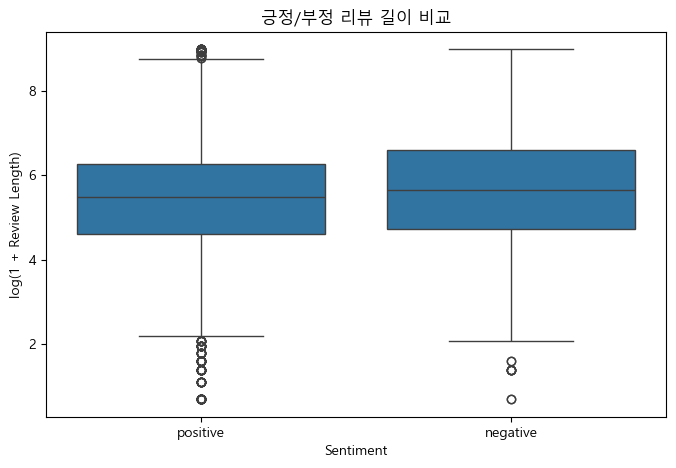

In [ ]:
reviews["log_review_length"] = np.log1p(reviews["review_length"])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=reviews,
    x="sentiment",
    y="log_review_length"
)

plt.title("긍정/부정 리뷰 길이 비교")
plt.xlabel("Sentiment")
plt.ylabel("log(1 + Review Length)")
plt.show()

플레이 타임을 전처리

In [ ]:
reviews["playtime_hours"] = (reviews["author_playtime_forever"] / 60).round(2)

reviews[["author_playtime_forever", "playtime_hours"]].head()

,author_playtime_forever,playtime_hours
0,4120,68.67
1,12951,215.85
2,3653,60.88
3,3280,54.67
4,12057,200.95


긍정과 부정별 플레이타임 비교

In [ ]:
playtime_summary = (
    reviews.groupby("sentiment")["playtime_hours"]
    .describe()
)

playtime_summary

,count,mean,std,min,25%,50%,75%,max
sentiment,,,,,,,,
negative,2766.0,53.057144,285.688676,0.08,2.02,7.030,21.365,7479.77
positive,10340.0,47.207232,179.387338,0.08,4.68,12.085,32.920,5221.40


중앙값만 보기

In [ ]:
reviews.groupby("sentiment")["playtime_hours"].median()

sentiment
negative     7.030
positive    12.085
Name: playtime_hours, dtype: float64

플레이 타임의 극단값이 너무 커서 로그변환 진행 후 시각화

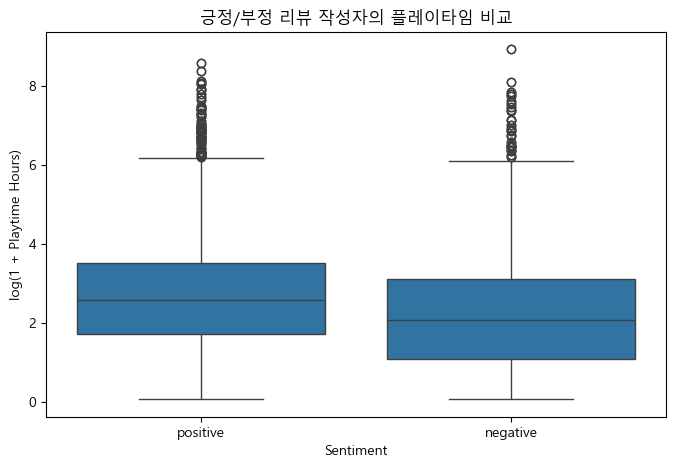

In [ ]:
reviews["log_playtime_hours"] = np.log1p(reviews["playtime_hours"])

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=reviews,
    x="sentiment",
    y="log_playtime_hours"
)

plt.title("긍정/부정 리뷰 작성자의 플레이타임 비교")
plt.xlabel("Sentiment")
plt.ylabel("log(1 + Playtime Hours)")
plt.show()

언어의 분포 확인

In [ ]:
language_summary = (
    reviews["language"]
    .value_counts()
    .reset_index()
)

language_summary.columns = ["language", "review_count"]
language_summary.head(20)

,language,review_count
0,english,5340
1,schinese,3570
2,russian,764
3,japanese,560
4,koreana,488
5,brazilian,478
6,spanish,382
7,tchinese,364
8,french,276
9,german,212


시각화

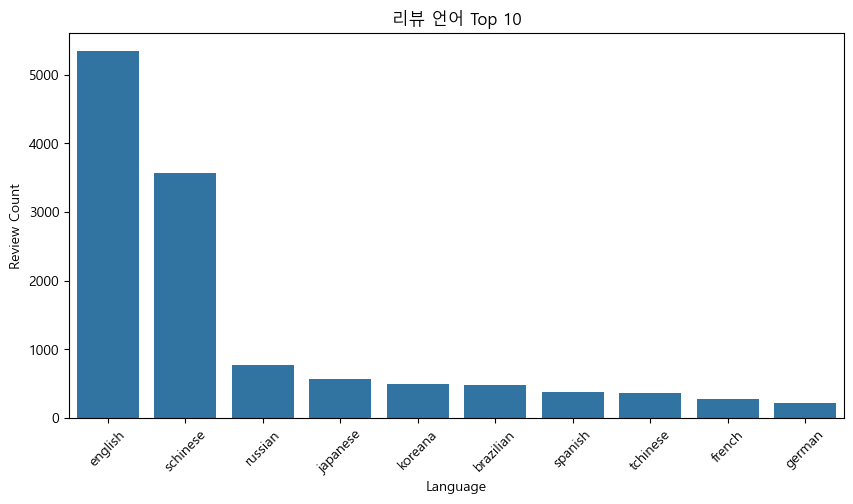

In [ ]:
top_lang = reviews["language"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_lang.index,
    y=top_lang.values
)

plt.title("리뷰 언어 Top 10")
plt.xlabel("Language")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.show()

언어별 긍정율 비율

In [ ]:
lang_sentiment = (
    reviews.groupby("language")
    .agg(
        review_count=("review", "count"),
        positive_ratio=("voted_up", "mean")
    )
    .sort_values("review_count", ascending=False)
)

lang_sentiment.head(20)

,review_count,positive_ratio
language,,
english,5338,0.787266
schinese,3570,0.760224
russian,764,0.790576
japanese,560,0.807143
koreana,488,0.778689
brazilian,478,0.899582
spanish,382,0.963351
tchinese,364,0.725275
french,276,0.920290


언어는 너무다양하기때문에 30개이상의 리뷰가 있는 리뷰만봐보자

In [ ]:
lang_sentiment_30 = lang_sentiment[
    lang_sentiment["review_count"] >= 30
].copy()

lang_sentiment_30.sort_values("positive_ratio", ascending=False)

,review_count,positive_ratio
language,,
spanish,382,0.963351
latam,100,0.940000
french,276,0.920290
thai,48,0.916667
brazilian,478,0.899582
polish,72,0.888889
turkish,138,0.869565
japanese,560,0.807143
italian,30,0.800000


시각화

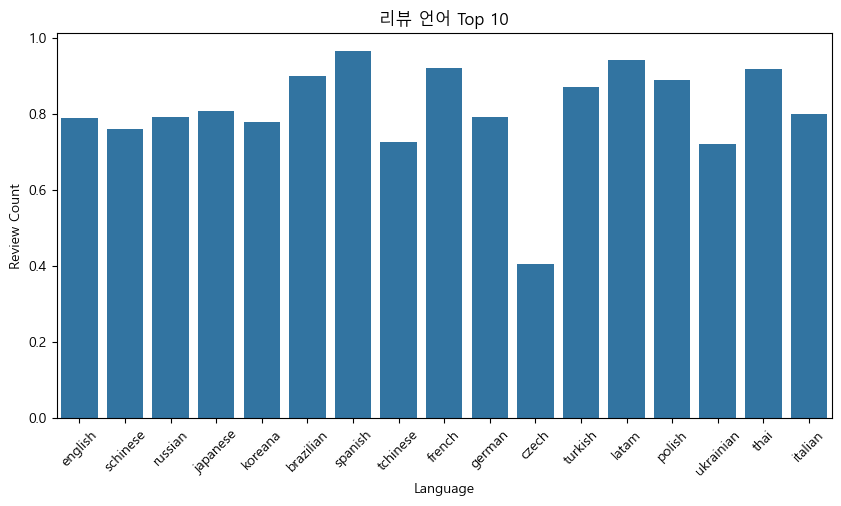

In [ ]:
pos_ratio = lang_sentiment_30

plt.figure(figsize=(10, 5))
sns.barplot(data = pos_ratio , x = 'language',y = 'positive_ratio')

plt.title("리뷰 언어 Top 10")
plt.xlabel("Language")
plt.ylabel("Review Count")
plt.xticks(rotation=45)
plt.show()

시간칼럼 변화

In [ ]:
reviews["created_date"] = pd.to_datetime(
    reviews["timestamp_created"],
    unit="s",
    errors="coerce"
)

reviews["created_month"] = reviews["created_date"].dt.to_period("M").astype(str)

reviews[["timestamp_created", "created_date", "created_month"]].head()

,timestamp_created,created_date,created_month
0,1678643330,2023-03-12 17:48:50,2023-03
1,1680018629,2023-03-28 15:50:29,2023-03
2,1681149417,2023-04-10 17:56:57,2023-04
3,1685034459,2023-05-25 17:07:39,2023-05
4,1681649431,2023-04-16 12:50:31,2023-04


In [ ]:
monthly_review = (
    reviews.groupby("created_month")
    .agg(
        review_count=("review", "count"),
        positive_ratio=("voted_up", "mean")
    )
    .reset_index()
)

monthly_review.head()

,created_month,review_count,positive_ratio
0,2023-02,396,0.904040
1,2023-03,180,0.844444
2,2023-04,224,0.857143
3,2023-05,450,0.680000
4,2023-06,188,0.723404


전체 리뷰 중 긍정 리뷰 비율은 약 78.9%로 나타났다.
부정 리뷰는 긍정 리뷰보다 리뷰 길이 중앙값이 길었고, 이는 불만 유저가 더 구체적인 문제를 작성했을 가능성을 보여준다.
플레이타임 기준으로는 부정 리뷰 작성자의 중앙 플레이타임이 더 높았다.
언어별로는 영어 리뷰가 가장 많았으며, 리뷰 수 30개 이상 언어 중 스페인 언어의 긍정 비율이 가장 높았다.

## 긍정리뷰와 부정리뷰 키워드 분석

영어로 작성된 리뷰로 먼저 확인작업 진행

In [ ]:
reviews_en = reviews[
    (reviews["language"] == "english") &
    (reviews["review"].notna())
].copy()

print(reviews_en.shape)
reviews_en[["review", "sentiment"]].head()

(5338, 28)


,review,sentiment
0,"For me, Sun Haven is a fun farming game that h...",positive
1,*Updated for v1.0.3*\n\nI really love this gam...,negative
2,(Singleplayer review)\nPuh i am not really sur...,positive
5,I want to make this short and as to the point ...,negative
6,TL; DR - No. No. Nonono. Get My Time at Sandro...,negative


In [ ]:
import re
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

reviews_en["clean_review"] = reviews_en["review"].apply(clean_text)

reviews_en[["review", "clean_review"]].head()

,review,clean_review
0,"For me, Sun Haven is a fun farming game that h...",for me sun haven is a fun farming game that ha...
1,*Updated for v1.0.3*\n\nI really love this gam...,updated for v i really love this game but that...
2,(Singleplayer review)\nPuh i am not really sur...,singleplayer review puh i am not really sure i...
5,I want to make this short and as to the point ...,i want to make this short and as to the point ...
6,TL; DR - No. No. Nonono. Get My Time at Sandro...,tl dr no no nonono get my time at sandrock or ...


불용어 제거후 단어 빈도 확인

In [ ]:
# from sklearn.feature_extraction.text import CountVectorizer

# stop_words = [
#     # 기본 영어
#     "the","and","is","it","to","of","a","in","for","this","that","you",
#     "with","on","as","are","was","but","be","have","not","so","if","at",
#     "by","an","or","from","they","we","he","she","them","his","her","our",
#     "their","its","who","what","which","when","where","why","how",

#     # 대명사/지시어
#     "i","me","my","mine","your","yours","our","ours","their","theirs",
#     "him","herself","himself","ourselves","themselves",

#     # 일반 동사 (의미 약함)
#     "get","got","make","made","go","went","take","took","use","used",
#     "try","tried","give","gave","come","came","want","wanted",
#     "see","seen","look","looked","find","found","think","thought",
#     "know","knew","keep","kept","put","set","run","ran",

#     # 시간/수량
#     "one","two","three","first","second","many","much","lot","lots",
#     "few","some","any","every","each","all",
#     "time","times","hour","hours","day","days","week","weeks","month","months",

#     # 게임 리뷰 흔한 단어
#     "game","games","play","playing","played","player","players",
#     "thing","things","way","something","anything","everything",
#     "stuff","part","parts","experience",

#     # 평가 표현 (너무 일반적)
#     "good","bad","great","nice","fun","boring","awesome","amazing",
#     "love","like","liked","hate","dislike","recommend","recommended",
#     "best","worst","better","worse","cool","enjoy","enjoyed",

#     # 강도/정도 표현
#     "really","very","pretty","quite","too","so","just","even","still",
#     "well","almost","maybe","probably","definitely","actually",

#     # 부정/축약형
#     "im","ive","dont","didnt","cant","couldnt","would","should",
#     "wasnt","werent","isnt","arent","doesnt","hadnt","hasnt","havent",

#     # 기타 잡단어
#     "yes","no","ok","okay","uh","um",
#     "etc","etc.","lol","haha","yeah","yep",

#     # 리뷰에서 흔히 나오는 무의미 단어
#     "edit","update","review","reviews","steam","pc","version","patch",
#     "dev","developer","devs","support","thanks",

#     # 숫자/단위 관련
#     "10","20","30","100","1000",
#     "fps","gb","mb"
# ]
    

# def get_top_words(data, sentiment_value, n=30):
#     text_data = data[data["sentiment"] == sentiment_value]["clean_review"]
    
#     vectorizer = CountVectorizer(
#         stop_words=stop_words,
#         min_df=3
#     )
    
#     word_matrix = vectorizer.fit_transform(text_data)
    
#     word_counts = word_matrix.sum(axis=0).A1
#     words = vectorizer.get_feature_names_out()
    
#     result = pd.DataFrame({
#         "word": words,
#         "count": word_counts
#     }).sort_values("count", ascending=False)
    
#     return result.head(n)

# positive_words = get_top_words(reviews_en, "positive", 30)
# negative_words = get_top_words(reviews_en, "negative", 30)

# positive_words

불용어를 아무리 추가해도 노이즈 자꾸 나옴 
방식변경 => TF-IDF방식
많이나오는 단어는 중요할 수 있어 가산점을 주지만 모든 곳에서 많이나온다면 의미가 없다고 판단하여 페널티를줘서
진짜 중요한 단어를 뽑아오는 기법

한개 단어만 보면 노이즈가 많을 가능성이 높기때문에 2단어 조합으로 보기

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
def get_tfidf_terms(data, sentiment_value, n=50):
    texts = data[data["sentiment"] == sentiment_value]["clean_review"]

    tfidf = TfidfVectorizer(
        stop_words="english",
        min_df=3,
        max_df=0.7,
        ngram_range=(2, 2) #(1,1) → 단어 1개
                           #(2,2) → 단어 2개
                           #(1,2) → 단어 + 2단어 둘 다
    )

    X = tfidf.fit_transform(texts)

    result = pd.DataFrame({
        "term": tfidf.get_feature_names_out(),
        "score": X.sum(axis=0).A1
    }).sort_values("score", ascending=False)

    return result.head(n)

positive_tfidf = get_tfidf_terms(reviews_en, "positive")
negative_tfidf = get_tfidf_terms(reviews_en, "negative")

positive_tfidf

,term,score
3018,good game,54.025162
2073,fun game,41.557146
3152,great game,36.902191
2392,game fun,32.040340
7030,ve played,31.124437
1480,early access,27.602323
2419,game great,25.971062
2574,game play,25.194392
1881,feels like,24.214964
4407,love game,23.926269


In [ ]:
negative_tfidf

,term,score
596,feels like,20.407446
1360,like game,17.732812
467,early access,17.268728
803,game just,16.296351
577,feel like,14.737077
771,game fun,10.881320
859,game play,10.175314
1916,recommend game,9.887919
879,game really,9.388536
301,current state,8.630391


good game, fun game등 노이즈가 많기 때문에 이런 단어 제거용 리스트 만들고 적용

추가적으로 게임타이틀을 쓰는 경우도 있기때문에 게임타이틀도 제거 진행

In [ ]:
noise_bigrams = [
    "good game", "fun game", "great game", "game fun", "game great",
    "game play", "love game", "game good", "recommend game",
    "game really", "play game", "like game", "game just",
    "game like", "really fun", "really good", "little game",
    "game love", "games like", "game ve", "playing game",
    "pretty good", "game lot", "buy game", "game amazing",
    "best game", "game feels", "game game", "game worth",
    "played game", "felt like", "feel like", "feels like",
    "game recommend", "amazing game", "ve played"
]
game_title_terms = [
    "duck detective",
    "luck landlord",
    "cod zombies"
]

bigram_df_clean = positive_tfidf[
    ~positive_tfidf["term"].isin(noise_bigrams)
].copy()

bigram_df_clean = bigram_df_clean[
    ~bigram_df_clean["term"].isin(game_title_terms)
].copy()

bigram_df_clean.head(50)

,term,score
1480,early access,27.602323
3328,highly recommend,20.952168
248,art style,20.690715
7077,voice acting,19.819757
7343,worth price,18.578401
4313,looking forward,18.230823
6320,steam deck,15.094327
6441,super fun,13.306001
3477,idle game,13.155948
1126,definitely worth,13.017634


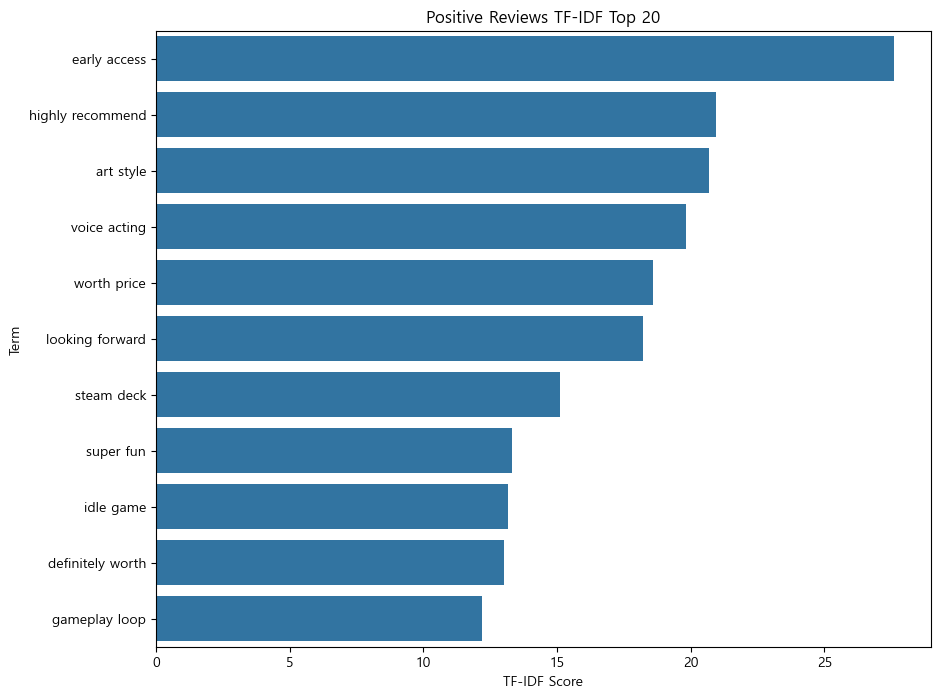

In [ ]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=bigram_df_clean.head(20),
    x="score",
    y="term"
)

plt.title("Positive Reviews TF-IDF Top 20")
plt.xlabel("TF-IDF Score")
plt.ylabel("Term")
plt.show()

In [ ]:
issue_keywords = {
    "bug_crash": ["bug", "bugs", "crash", "crashes", "crashed", "glitch", "broken"],
    "performance": ["lag", "fps", "performance", "optimization", "stutter", "slow"],
    "server_online": ["server", "servers", "disconnect", "online", "multiplayer", "matchmaking"],
    "price_value": ["price", "expensive", "worth", "refund", "money", "paid"],
    "repetitive_content": ["repetitive", "grind", "content", "boring", "same"],
    "control_ux": ["control", "controls", "ui", "menu", "tutorial"],
    "balance_difficulty": ["balance", "difficulty", "hard", "unfair", "easy"]
}

In [ ]:
def tag_issues(text):
    text = str(text).lower()
    tags = []

    for category, keywords in issue_keywords.items():
        if any(keyword in text for keyword in keywords):
            tags.append(category)

    return tags

negative_reviews = reviews_en[reviews_en["sentiment"] == "negative"].copy()

negative_reviews["issue_tags"] = negative_reviews["clean_review"].apply(tag_issues)

negative_reviews[["review", "issue_tags"]].head()

,review,issue_tags
1,*Updated for v1.0.3*\n\nI really love this gam...,"[bug_crash, performance, server_online, price_..."
5,I want to make this short and as to the point ...,"[bug_crash, performance, server_online, price_..."
6,TL; DR - No. No. Nonono. Get My Time at Sandro...,"[bug_crash, server_online, price_value, repeti..."
17,This game needs more negative reviews.\n\nThis...,"[bug_crash, price_value, repetitive_content, c..."
20,I was indifferent until the devs did the follo...,"[bug_crash, price_value, control_ux]"


In [ ]:
from collections import Counter

issue_counter = Counter()

for tags in negative_reviews["issue_tags"]:
    issue_counter.update(tags)

issue_summary = pd.DataFrame(
    issue_counter.items(),
    columns=["issue_category", "count"]
).sort_values("count", ascending=False)

issue_summary

,issue_category,count
5,control_ux,494
4,repetitive_content,358
3,price_value,344
6,balance_difficulty,284
0,bug_crash,216
1,performance,162
2,server_online,40


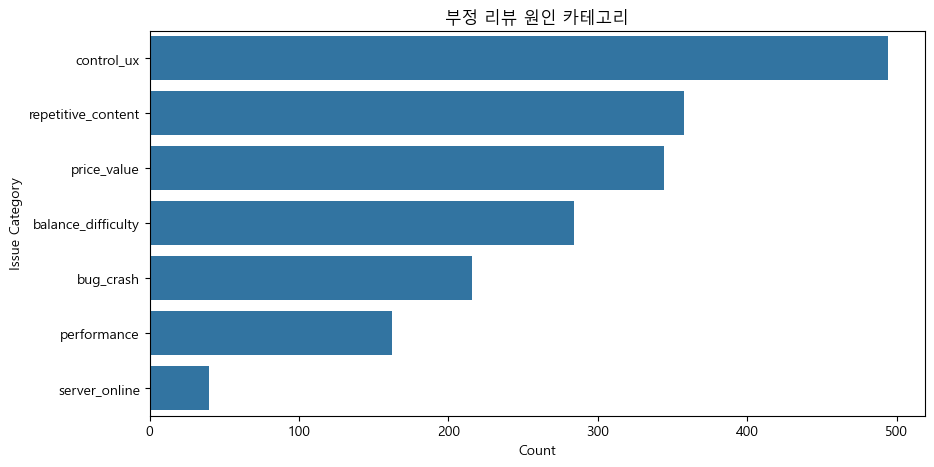

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=issue_summary,
    x="count",
    y="issue_category"
)

plt.title("부정 리뷰 원인 카테고리")
plt.xlabel("Count")
plt.ylabel("Issue Category")
plt.show()